In [1]:
import pandas as pd
import scipy.stats
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import TargetEncoder
from concurrent.futures import ThreadPoolExecutor
import itertools
import gc
from lightgbm import LGBMClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
import warnings
warnings.filterwarnings("ignore")

As a reminder, to save computation cost, the data we are loading were features constructed using the non-validation partition. 

This dataframe does not contain the out-of-time validation set, nor does it contain the first two weeks of data (to ensure stability in features).

In [2]:
df = pd.read_parquet("data/candidate_variables.parquet")
df.drop(columns=['Recnum', 'Date', 'Cardnum', 'Merchnum', 'Amount',
            'Merch description', 'Merch state', 'Merch zip', 'DayOfWeek'], inplace=True)

In [3]:
df.shape

(81892, 6874)

## Procedure
This notebook follows a two-step procedure to select strong features. 
- Stage 1: Filters out weak candidate features by ranking the Kolmogorov-Smirnov statistic. (Select Top N)
- Stage 2: Uses Sequential Feature Selection to iteratively test for predictive performance. 

In [4]:
NUM_OUT_OF_FILTER = 1375  # Top variables to keep after KS filter (10-20% of total)
NUM_OUT_OF_WRAPPER = 20  # Final variables after wrapper selection
DETECT_RATE = 0.03       # Top 3% for Fraud Detection Rate calculation

print(f"{df.shape[0]} rows, {df.shape[1]-1} candidate features")

81892 rows, 6873 candidate features


### Stage 1: Kolmogorov-Smirnov Statistic

In [5]:
# random variable as control (should not be selected)
df['RANDOM'] = np.random.rand(len(df))

frauds = df[df['Fraud'] == 1]
non_frauds = df[df['Fraud'] == 0]

print(f"Class distribution: {len(frauds)} frauds, {len(non_frauds)} non-frauds")

Class distribution: 1975 frauds, 79917 non-frauds


In [6]:
ks_scores = []

for col in tqdm(df.columns):
    if col == 'Fraud':
        continue
    
    ks_stat = scipy.stats.ks_2samp(non_frauds[col], frauds[col])[0]
    ks_scores.append({'variable': col, 'filter_score': ks_stat})

filter_score = pd.DataFrame(ks_scores).sort_values('filter_score', ascending=False)

print(f"\nTop 20 features by KS score:")
print(filter_score.head(20))

100%|██████████| 6875/6875 [00:36<00:00, 188.18it/s]


Top 20 features by KS score:
                   variable  filter_score
14          Cardnum_total_1      0.565635
389        card_dow_total_0      0.544130
407        card_dow_total_3      0.544130
398        card_dow_total_1      0.544130
23          Cardnum_total_3      0.539515
12            Cardnum_max_1      0.537268
5           Cardnum_total_0      0.532368
405          card_dow_max_3      0.532188
396          card_dow_max_1      0.532188
387          card_dow_max_0      0.532188
10          Cardnum_count_1      0.527061
19          Cardnum_count_3      0.523435
3             Cardnum_max_0      0.516872
404          card_dow_avg_3      0.510367
395          card_dow_avg_1      0.510367
386          card_dow_avg_0      0.510367
388          card_dow_med_0      0.508648
397          card_dow_med_1      0.508648
406          card_dow_med_3      0.508648
2087  Cardnum_vdratio_1by60      0.502717


In [7]:
# keep top N
vars_keep = filter_score['variable'].head(NUM_OUT_OF_FILTER).tolist()
print(f"Retaining {len(vars_keep)} features for wrapper selection")

X = df[vars_keep]
y = df['Fraud']

Retaining 1375 features for wrapper selection


### Fraud Detection Rate

In [8]:
# SFS expects this input format during cross-validation
def fdr_sfs_scorer(estimator, X, y):
    # we define DETECT_RATE above
    
    try:
        y_prob = estimator.predict_proba(X)
    except Exception as e:
        print(f"Prediction Error: {e}")
        return 0.0

    # - Shape Handling -
    # handle LightGBM's output (N, 2) or (N, 1)
    # since fraud is rare, possible for one fold to have only one class, outputting (N, 1)
    if hasattr(y_prob, 'ndim') and y_prob.ndim > 1:
        # If we have a 2nd column (positive class), use it. Otherwise use the first (only) column.
        target_col = 1 if y_prob.shape[1] > 1 else 0
        y_prob = y_prob[:, target_col]
    
    y_prob = np.asarray(y_prob).flatten()
    y_true = np.asarray(y)

    # - FDR Calculation -
    n_top = max(1, int(len(y_true) * DETECT_RATE))
    top_indices = np.argsort(y_prob)[-n_top:]   # argsort sorts low -> high, so we take the last n_top
    total_frauds = np.sum(y_true == 1)
    
    if total_frauds == 0:
        return 0.0
        
    frauds_caught = np.sum(y_true[top_indices] == 1)
    
    return float(frauds_caught / total_frauds)

### Stage 2: Sequential Feature Selection

In [9]:
# classifier (clf)
clf = LGBMClassifier(n_estimators=20, num_leaves=4, verbose=-1)

sfs = SFS(
    clf,
    k_features=NUM_OUT_OF_WRAPPER,
    forward=True,
    verbose=1,
    scoring=fdr_sfs_scorer,
    cv=2,
    n_jobs=-1
)

sfs.fit(X, y)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   10.3s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   13.9s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:   19.9s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:   27.5s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:   38.2s
[Parallel(n_jobs=-1)]: Done 1375 out of 1375 | elapsed:   41.6s finished
Features: 1/20[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:   11.6s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:   20.5s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:   31.8s
[Parallel(n_jobs=-1)]: Done 1374 out of 1374 | elapsed:   35.3s finished
Features: 2/20[Parallel(n_jobs=-1)]: Using backend LokyBackend wit

,estimator,"LGBMClassifie...4, verbose=-1)"
,k_features,"(20, ...)"
,forward,True
,floating,False
,verbose,1
,scoring,<function fdr...00203C4D6E710>
,cv,2
,n_jobs,-1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


### Results & Visualization

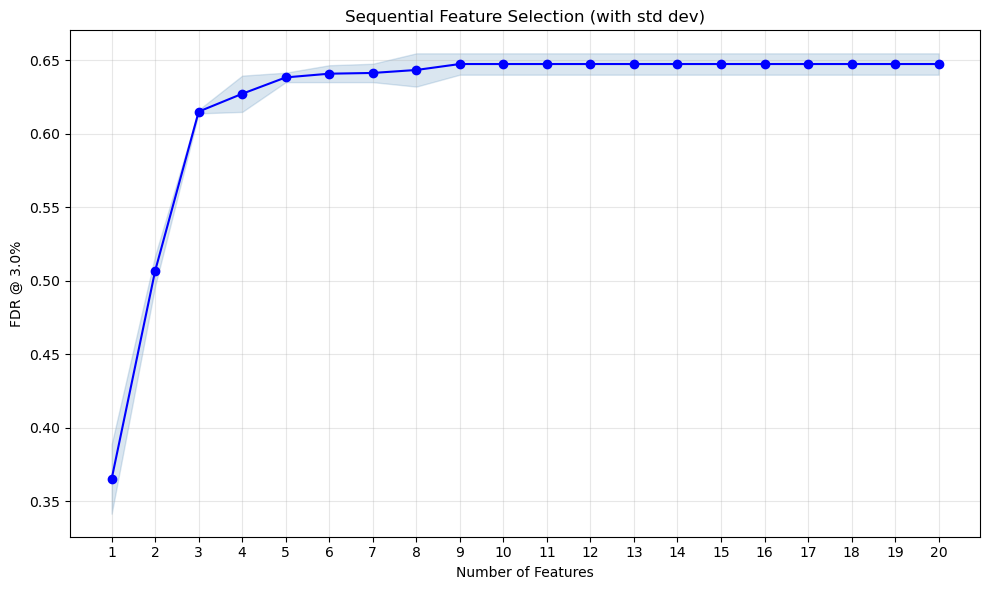

In [10]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig1 = plot_sfs(sfs.get_metric_dict(), kind='std_dev', figsize=(10, 6))
plt.title('Sequential Feature Selection (with std dev)')
plt.xlabel('Number of Features')
plt.ylabel(f'FDR @ {DETECT_RATE*100}%')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
md = sfs.get_metric_dict()
order, prev = [], set()
for step in sorted(md, key=lambda x: int(x)):
    curr = set(md[step]['feature_names'])
    add = curr - prev
    if add:
        order.append(next(iter(add)))
    prev = curr

ks = dict(zip(filter_score['variable'], filter_score['filter_score']))
for i, feat in enumerate(order, 1):
    print(f"{i:2d}. {feat}: KS = {ks.get(feat, np.nan):.4f}")

 1. Cardnum_vdratio_1by14: KS = 0.4830
 2. card_merchdesc_zip_total_14: KS = 0.1650
 3. Cardnum_unique_count_for_card_state_3: KS = 0.4418
 4. merch_zip_actual/med_60: KS = 0.2269
 5. card_zip_unique_count_for_merchnum_dow_60: KS = 0.1749
 6. Cardnum_count_1_by_7: KS = 0.4329
 7. card_dow_unique_count_for_card_merchnum_zip_60: KS = 0.3033
 8. card_state_variability_max_3: KS = 0.1996
 9. merchnum_desc_state_actual/avg_60: KS = 0.1812
10. Cardnum_count_1_by_7_sq: KS = 0.4329
11. Cardnum_unique_count_for_card_dow_1: KS = 0.3300
12. card_dow_actual/med_7: KS = 0.3127
13. card_dow_actual/avg_7: KS = 0.3107
14. card_dow_actual/max_7: KS = 0.3086
15. card_dow_unique_count_for_merch_zip_60: KS = 0.3033
16. card_dow_unique_count_for_Merchnum_60: KS = 0.3030
17. card_dow_unique_count_for_merch_state_60: KS = 0.3030
18. card_dow_unique_count_for_card_merch_60: KS = 0.3030
19. card_dow_unique_count_for_merchnum_dow_60: KS = 0.3030
20. card_dow_unique_count_for_card_merchnum_state_60: KS = 0.3030


In [17]:
df_ks = pd.DataFrame({
    'feature': order,
    'wrapper_order': range(1, len(order) + 1),
    'ks_stat': [ks.get(f, np.nan) for f in order]
})

In [19]:
out_path = 'data/selected_features_ks.csv'
df_ks.to_csv(out_path, index=False)